# Distributed Intelligence in the Computing Continuum

This tutorial describes a complete feedback cycle for an adaptive stream processing service that optimizes its performance throughout evolving requirements. The core phases of this cycle, following the traditional MAPE-K loop, are:

1. **Monitor**: Collect service telemetry
2. **Analyze**: Regression analysis of structural knowledge
3. **Plan**: Intent-based inference
4. **Execute**: Service scaling

Note that this abstract cycle can be implemented through various technologies and the ones presented in this tutorial present only one of many possibilities.

To reduce the experimental overhead of this tutorial, we do not actually run any physical services; instead, we operate on a prerecorded dataset that tracks the service behavior during runtime. Interested participants can find the complete experimental platform in this [repository](github.com/borissedlak/elastic-workbench).



## General Setup

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('default')

from agent.components import RASK
from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType, theoretical_param_bounds, ServiceVar, FIG_SIZE_DEFAULT
from agent.components.commons import SloSet

services = [ServiceType.QR, ServiceType.CV, ServiceType.PC]
slos = [SloSet.DEFAULT, SloSet.HIGH_PERF, SloSet.LOW_COST, SloSet.HIGH_QUALITY]

## **Monitor**: Service Telemetry

In [2]:
# TODO: Here I can just show the data structure

df_explore = pd.read_csv("../../statics/agent_experience/metrics_TSC_EXPLORE.csv")
df_explore_preprocessed = RASK.preprocess_data(df_explore)

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str


## **Analyze**: Regression Analysis of Structural Knowledge

### Create Structural Knowledge

### Functional Data Analysis

In [3]:
# import plotly.io as pio
#
# print(pio.renderers)
# pio.renderers.default = "chrome"
# import plotly
# import jupyterlab
#
# print(plotly.__version__)
# print(jupyterlab.__version__)

# for type in ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
#          'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
#          'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
#          'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
#          'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']:

In [4]:
# TODO: Give the option to change between interactive plot and not; the static
#  plot would also always render withing the notebook.

import plotly.io as pio
pio.renderers.default = 'browser'

gp_list = []
lml_history = []

split_data_into_x_parts = 10
iterate_through_x_parts = 10

for i in range(iterate_through_x_parts):
    gp_all_services = {}
    data_ratio = (i + 1) / split_data_into_x_parts
    lml_all_service = []

    for s in services:
        # Initialize and train GP model
        draw_figures = i == 0 or i == iterate_through_x_parts - 1
        _gp = GASK(s, create_figures=draw_figures, display_figures=draw_figures)
        _gp.init_model(df_explore, data_density=data_ratio)

        _lml = _gp.get_model_lml(s, "max_tp")
        lml_scaled = _lml / data_ratio
        lml_all_service.append(lml_scaled)
        # print(f"Ratio {data_ratio}: LML = {lml:.2f}")
        gp_all_services[s] = _gp

    lml_history.append(lml_all_service)
    gp_list.append(gp_all_services)

    print(f"Finished {i + 1} / {iterate_through_x_parts} of the Gaussian Processes")

lml_history = np.array(lml_history)


INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:draw_3d_gp_plot took 541 ms to execute
INFO:multiscale:train_gp_models took 625 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max

Finished 1 / 10 of the Gaussian Processes


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 654 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a bett

Finished 2 / 10 of the Gaussian Processes


INFO:multiscale:train_gp_models took 283 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
INFO:multiscale:train_gp_models took 439 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-pc-visualizer - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.

...

Finished 8 / 10 of the Gaussian Processes


INFO:multiscale:train_gp_models took 442 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
INFO:multiscale:train_gp_models took 482 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-pc-visualizer - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.

Finished 9 / 10 of the Gaussian Processes


INFO:multiscale:draw_3d_gp_plot took 398 ms to execute
INFO:multiscale:train_gp_models took 1066 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
INFO:multiscale:draw_3d_gp_plot took 529 ms to execute
INFO:multiscale:train_gp_models took 1643 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-pc-visualizer - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to

Finished 10 / 10 of the Gaussian Processes


#### Create LML Figure

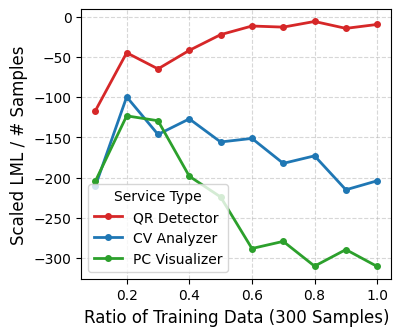

In [5]:
# 1. Define the X-axis (Data Ratios)
data_ratios = np.arange(1, iterate_through_x_parts + 1) / split_data_into_x_parts

# 2. Create the Figure
plt.figure(figsize=FIG_SIZE_DEFAULT)

# Service labels matching your 'services' list order
labels = ['QR Detector', 'CV Analyzer', 'PC Visualizer']
colors = ['#d62728', '#1f77b4', '#2ca02c']  # Red, Blue, Green

for i in range(lml_history.shape[1]):
    plt.plot(data_ratios * (split_data_into_x_parts / iterate_through_x_parts), lml_history[:, i],
             marker='o', markersize=4, linewidth=2,
             label=labels[i], color=colors[i])

# 3. Formatting
abs_samples = int(len(df_explore) * (iterate_through_x_parts / split_data_into_x_parts))
plt.xlabel(f'Ratio of Training Data ({int(abs_samples / 3)} Samples)', fontsize=12)
plt.ylabel('Scaled LML / # Samples', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Service Type")
plt.show()

In [6]:

# plt.savefig('../../figures/E1/training/lml_convergence.pdf')

RUN_HEATMAP = False # TODO: Does the heatmap provide some benefit?
if RUN_HEATMAP:

    from agent.components.GaussianProcess import get_empirical_variable_bounds
    from utils import visualize_ndarray
    from agent.components.commons import ServiceVar
    from typing import Dict
    from agent.components.Optimizer import VersatileMapElites


    def extract_pfo_for_SLOs(gp_service, slos: Dict[ServiceVar, float], slo_type: str, simple_bounds):
        v_me = VersatileMapElites(gp_service.s_type, bins=8)

        #  I'm getting the black cells because they are not explored.
        #  What I can do is force all cells to be explored at least once,
        #  or just run gradient descent for each cell multiple (like 5) times.
        v_me.run_search(slos, gp_service, simple_bounds, iterations=2000)
        visualize_ndarray(v_me.fitness_table, gp_service.s_type.value + "_" + slo_type, cmap="viridis")


    final_empirical_bounds = get_empirical_variable_bounds(df_explore_preprocessed)[ServiceType.QR]
    simple_param_bounds = final_empirical_bounds.copy()
    del simple_param_bounds[ServiceVar.PERFORMANCE]
    simple_param_bounds = list(simple_param_bounds.values())

    candidate_solutions = []
    # (1) Here I give it increasingly more training data
    for i in range(iterate_through_x_parts):
        candidates = extract_pfo_for_SLOs(gp_list[i][ServiceType.QR], SloSet.DEFAULT.value, "DEFAULT",
                                          simple_param_bounds)
        candidate_solutions.append(candidates)


## **Plan**: Intent-based Inference

Find optimal parameter configs for each SLO x Service combination after seeing certain data shares

**TODO**: This here could actually be the place where we introduce out multi-dimensional methodology

In [7]:
from agent.components.Optimizer import run_optimizer_multi

solution_history = []

for i in range(iterate_through_x_parts):
    for q in slos:
        for s in services:
            data_ratio = (i + 1) / iterate_through_x_parts
            gp = gp_list[i][s]

            # Run optimizer to find the best configuration
            solutions = run_optimizer_multi(s, q.value, gp, theoretical_param_bounds[s], runs=25)
            fitness, config = max(solutions, key=lambda x: x[0])

            # Predict performance (mu, sigma) for the chosen configuration
            x_state = {ServiceVar.COST: config[0], ServiceVar.QUALITY: config[1]}
            x_state = x_state | ({ServiceVar.MODEL: config[2]} if s == ServiceType.CV else {})
            mu, sigma = gp.predict(s, "max_tp", x_state)

            # Store everything needed for the next block
            # We include empirical_var_bounds here as it changes per iteration
            solution_history.append({
                'data_rate': data_ratio,
                'rep': None,
                'service_type': s.value,
                'slo_set': q.name,
                'p_fitness': fitness,
                'dist': (mu, sigma),
                'cores': x_state[ServiceVar.COST],
                'data_quality': x_state[ServiceVar.QUALITY],
                'model_size': x_state[ServiceVar.MODEL] if s == ServiceType.CV else -1,
            })

            print(f"Optimal fitness for {s.value} and {q.name} with {data_ratio * 100}% training data: {fitness}")

Optimal fitness for elastic-workbench-qr-detector and DEFAULT with 10.0% training data: 0.47050985372080395
Optimal fitness for elastic-workbench-cv-analyzer and DEFAULT with 10.0% training data: 0.48637655921962325
Optimal fitness for elastic-workbench-pc-visualizer and DEFAULT with 10.0% training data: 0.9059247165864057
Optimal fitness for elastic-workbench-qr-detector and HIGH_PERF with 10.0% training data: 0.9031123138690496
Optimal fitness for elastic-workbench-cv-analyzer and HIGH_PERF with 10.0% training data: 0.8359790688197124
Optimal fitness for elastic-workbench-pc-visualizer and HIGH_PERF with 10.0% training data: 0.926090864888433
Optimal fitness for elastic-workbench-qr-detector and LOW_COST with 10.0% training data: 0.8570137205036048
Optimal fitness for elastic-workbench-cv-analyzer and LOW_COST with 10.0% training data: 0.8708928620919036
Optimal fitness for elastic-workbench-pc-visualizer and LOW_COST with 10.0% training data: 0.923082822959961


KeyboardInterrupt: 

#### Export to candidate solution script, with each config repeated x times

In [ ]:

repeatable_data = []
runs_per_config = 50

# Iterate through the list in steps of 3 (the size of your service triple)
for i in range(0, len(solution_history), 3):
    # Extract the current triple of rows
    triple = solution_history[i: i + 3]

    # Repeat this specific triple for the number of runs
    for run_idx in range(runs_per_config):
        for row in triple:
            new_row = row.copy()
            new_row['rep'] = run_idx + 1
            repeatable_data.append(new_row)

df_candidates = pd.DataFrame(repeatable_data)
df_candidates.to_csv(f'../statics/candidates/candidate_solutions_{iterate_through_x_parts}_{split_data_into_x_parts}_{runs_per_config}.csv', index=False)


## **Execute**: Service Scaling

**TODO**: This part would be totally simulated again. The thing is that here we would need some feedback loop. So that the action we take is actually reflected. But the agent experience should feature that? Or in particular the TSC submission. But this means I would also need to use the exploration data from there.